In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble  import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

In [ ]:
df=pd.read_csv('/content/IMDb Movies India.csv', encoding='latin1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [ ]:
df= df[['Genre','Director','Actor 1','Actor 2','Actor 3','Votes','Duration','Rating']]

In [ ]:
df=df.dropna()

In [ ]:
df['Votes']=df['Votes'].str.replace(',','').astype(int)

In [ ]:
df['Duration']=df['Duration'].str.replace('min','').astype(int)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Genre']=le.fit_transform(df['Genre'])
df['Director']=le.fit_transform(df['Director'])
df['Actor 1']=le.fit_transform(df['Actor 1'])
df['Actor 2']=le.fit_transform(df['Actor 2'])
df['Actor 3']=le.fit_transform(df['Actor 3'])

In [ ]:
x=df.drop('Rating',axis=1)
y=df['Rating']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model=RandomForestRegressor(n_estimators=200,max_depth=10,random_state=42)
model.fit(x_train,y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse =np.sqrt(mse)

In [ ]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 0.9888858866272421
Mean Squared Error: 1.547902107879525
Root Mean Squared Error: 1.244147140767331


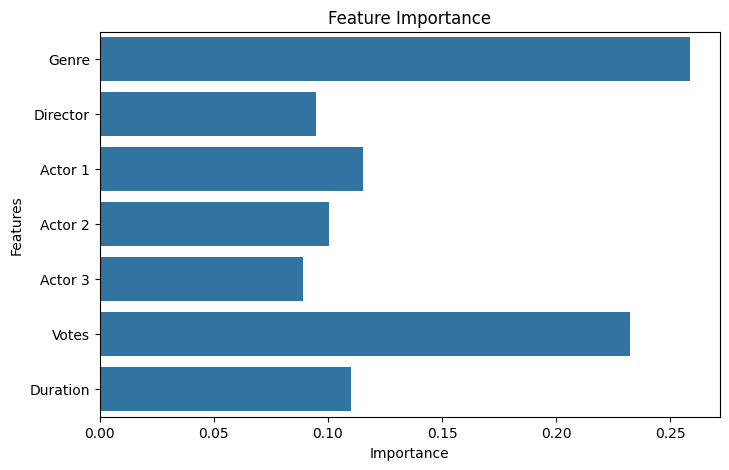

In [ ]:
importance =model.feature_importances_
features=x.columns
plt.figure(figsize=(8,5))
sns.barplot(x=importance,y=features)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()


In [ ]:
sample =[[2,150,300,400,500,100000,120]]
prediction =model.predict(sample)
print("predicted movie rating:",prediction)

predicted movie rating: [5.97490303]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import r2_score
r2= r2_score(y_test,y_pred)
accuracy = r2*100
print("r2 score:",r2)
print("model accuracy:", accuracy,"100%")

r2 score: 0.1640840182637947
model accuracy: 16.40840182637947 100%
